In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read,write
from ase.build.surface import mx2
from ase.calculators.espresso import Espresso
from ase.io import read,write
from os import environ,chdir
from ase.optimize import BFGS
from ase.constraints import FixedLine
from mace.calculators import MACECalculator

a = {}
a['WS2'] = 3.190902132
a['MoS2'] = 3.186305534
a['WSe2'] = 3.322874304
a['MoSe2'] = 3.322339468

t = {}
t['WS2'] = 3.1570497014
t['MoS2'] = 3.140170013
t['WSe2'] = 3.367178811
t['MoSe2'] = 3.3492559072

def get_tmdc_bilayer(tmdc1,tmdc2,a_tmd,N,offset,d,parallel):
    
    t = {}
    t['WS2'] = 3.1570497014
    t['MoS2'] = 3.140170013
    t['WSe2'] = 3.367178811
    t['MoSe2'] = 3.3492559072
    
    ## Make tmdc monolayers and align them with the axes
    sup_tmdc1 = mx2(tmdc1,kind='2H',a=a_tmd,thickness=t[tmdc1],vacuum=8,size=(N,N,1))
    sup_tmdc1.rotate(60,[0,0,1],rotate_cell=True)
    sup_tmdc2 = mx2(tmdc2,kind='2H',a=a_tmd,thickness=t[tmdc2],vacuum=8,size=(N,N,1))
    sup_tmdc2.rotate(60,[0,0,1],rotate_cell=True)
    
    #Rotate 180 degrees to get XX' antiparallel stacking
    if not parallel:
        
        sup_tmdc2.rotate(180,sup_tmdc2.positions[1]-sup_tmdc2.positions[2],
                        center=(sup_tmdc2.positions[1]+sup_tmdc2.positions[2])/2)
        
    #Get unit lattice vectors
    #v1,v2,v3 = prim_tmdc2.get_cell()
    unit_v1 = np.array([1,0,0])
    unit_v2 = np.array([0,1,0])
    unit_v3 = np.array([0,0,1])
    
    #Get translation vector from offset and interlayer distance d
    translate_v1 = a_tmd*offset[0]*unit_v1
    translate_v2 = a_tmd*offset[1]*unit_v2
    translate_v3  = (d)*unit_v3
    
    sup_tmdc2.translate(translate_v1+translate_v2+translate_v3)
    
    bilayer = sup_tmdc1 + sup_tmdc2
    
    return bilayer

def passlog():
    pass

#Load MACE model
model_path = '/home/theory/phrrpq//Research_Data/quaternary_test/bilayer_models/MoWSSe_bi_radius_8_reduced_all_1_swa_800_run-123_swa.model'
CALC = MACECalculator(model_paths=model_path, device="cuda", default_dtype="float64")

#Environment variable and pseudopotential directory for Espresso input files
environ["ASE_ESPRESSO_COMMAND"]="mpirun -n 24 /storage/nanosim/qe-7.0/bin/pw.x -in PREFIX.pwi >> PREFIX.pwo"
pseudo_dir = '/home/theory/phrrpq/GBRV_PBE/'

#Function for generating Espresso input files
def singlepoint(model,label,func,cutoff,kpts='gamma',pseudos=None,metal=False,spin=0,
                forces=True,stresses=False,writeonly=False,readonly=False,
                calconly=False,mdtemp=None):

    input_data = {
        'control': {
             'pseudo_dir': pseudo_dir,
             'prefix': label,
             'restart_mode': 'from_scratch',
             'tprnfor': forces,
             'tstress': stresses},
        'system': {
             'ecutwfc': cutoff,
             'ecutrho': float(cutoff)*9,
             'ibrav'  : 0,
             'input_dft': func}, 
        'electrons': {
             'startingpot': 'file',
             'startingwfc': 'atomic',
             'conv_thr': 1e-9,
             'mixing_beta': 0.5},
        'disk_io': 'low'} 

    if metal:
        input_data['system']['occupations'] = 'smearing'
        input_data['system']['smearing'] = 'gaussian'
        input_data['system']['degauss'] = 0.0005
    if spin != 0:
        input_data['system']['tot_magnetization'] = spin
        input_data['system']['nspin'] = 2
    calculation = 'scf'

    calc = Espresso(label=label,pseudo_dir=pseudo_dir,calculation=calculation, kpts=kpts,
             tstress=stresses,tprnfor=forces,pseudopotentials=pseudos,xc=func,
             input_data=input_data)

    model.set_calculator(calc)
    if writeonly:
        if hasattr(calc,'template'):
            from ase.io.espresso import write_espresso_in
            write_espresso_in(open(f"{label}.pwi","w"),model,input_data,pseudos,kpts=kpts)
        else:
            calc.write_input(model)
        return
    if readonly:
        if hasattr(calc,'template'):
            calc.template.read_results(calc.directory)
        else:
            calc.read_results(model)
        energy = calc.get_property('energy',atoms=model,allow_calculation=False)
        if forces:
            forces = calc.get_property('forces',atoms=model,allow_calculation=False)
    else:
        energy = model.get_potential_energy()
        if forces:
            forces = model.get_forces()
    return energy, forces

from ase.io import Trajectory

#Pseudopotential names in pseudo dir
pseudos = {'Mo': 'mo_pbe_v1.uspp.F.UPF','S': 's_pbe_v1.4.uspp.F.UPF','W':'w_pbe_v1.2.uspp.F.UPF','Se':'se_pbe_v1.uspp.F.UPF'}


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using head Default out of ['Default']


Starting calculations for P-MoS2/WS2
XX' -1.8292088290738306 -1.8358318021496227 -1.8226144877293886
2 -2.0324450201476574 -2.0402677834146608 -2.0246668868688538
3R(MX') -2.489418504078436 -2.4955113564173734 -2.4833721066731003
4 -2.3127458563803915 -2.3200592672858953 -2.305485505351919
3R(XM') -2.482236287025072 -2.4882117647745345 -2.476310382120959
6 -2.100720797961118 -2.1086539933942934 -2.0928369634237587
Starting calculations for AP-MoS2/WS2
XX' -1.836416725411521 -1.8431495213731186 -1.8297123529874708
2 -2.052010070051083 -2.0597445348184467 -2.044321556837874
2H -2.513820709667164 -2.519259955854064 -2.508425529815054
4 -2.014498562198148 -2.0224068275461318 -2.0066346712078795
MM' -2.396557769832294 -2.403821231559376 -2.3893441446802117
6 -2.10112646291502 -2.109058316506091 -2.0932439809330767
Starting calculations for P-MoSe2/WSe2
XX' -1.8020882292016835 -1.8028709995941867 -1.801305681759781
2 -1.9523234693177773 -1.9532073557303322 -1.9514398499720003
3R(MX') -2.3197

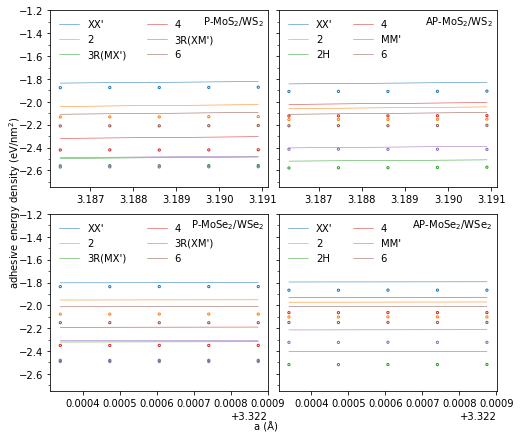

In [6]:
# tmdc1 = 'MoS2'
# tmdc2 = 'WS2'
# 1-> XX' 2-> 2 3-> MX' 4-> 4 5 -> XM' 6 -> f(d)
P_offsets = np.array([[0,0],[0,1/(2*np.sqrt(3))],
            [0,-1/np.sqrt(3)],[0,1*np.sqrt(3)/2],
            [0,1/np.sqrt(3)],[-1/3,1/np.sqrt(3)]])

# 1-> XX' 2-> 2 3-> 2H 4-> 4 5 -> MM' 6 -> f(d)
AP_offsets = np.array([[0,0],[0,-1/(2*np.sqrt(3))],
            [0,-1/np.sqrt(3)],[0,1/(2*np.sqrt(3))],
            [0,1/np.sqrt(3)],[-1/3,0]])

P_stacks = {1:"XX'",2:"2",3:"3R(MX')",4:"4",5:"3R(XM')",6:"6"}
AP_stacks = {1:"XX'",2:"2",3:"2H",4:"4",5:"MM'",6:"6"}
stacknames = [P_stacks,AP_stacks]

# chdir('alat_espresso/')
from matplotlib.ticker import MultipleLocator
fontsize = 10
plt.rcParams['font.size'] = fontsize

fig,axs = plt.subplots(2,2,figsize=(8,7))

mae_heteros = np.zeros(4)

for i,(tmdc1,tmdc2) in enumerate([('MoS2','WS2'),('MoSe2','WSe2')]):
    
    a_tmds = np.linspace(a[tmdc1],a[tmdc2],5)
    
    #Storing monolayer energies for adhesive energy calculations
    mono1_energies_mace = np.zeros(len(a_tmds))
    mono2_energies_mace = np.zeros(len(a_tmds))
    mono1_energies_espr = np.zeros(len(a_tmds))
    mono2_energies_espr = np.zeros(len(a_tmds))
    
    
    
    for l,a_tmd in enumerate(a_tmds):
        mono1 = mx2(tmdc1,kind='2H',a=a_tmd,thickness=t[tmdc1],vacuum=8,size=(1,1,1))
        mono1.calc = CALC
        dyn = BFGS(mono1)
        dyn.log = passlog
        dyn.run(fmax=0.001)
        mono1_energies_mace[l] = mono1.get_potential_energy()
        
        filename = f'alat_espresso/{tmdc1}_{tmdc2}_mono1_alat{l+1}.pwo'
        mono1_energies_espr[l] = read(filename).get_potential_energy()
        
        
#         filename = f'{tmdc1}_{tmdc2}_mono1_alat{l+1}'
#         singlepoint(mono1,f'{filename}',
#             'VDW-DF-OBK8',50,kpts=(12,12,1),
#             pseudos=pseudos,metal=False,stresses=True,
#             writeonly=True)
        
        mono2 = mx2(tmdc2,kind='2H',a=a_tmd,thickness=t[tmdc2],vacuum=8,size=(1,1,1))
        mono2.calc = CALC
        dyn = BFGS(mono2)
        dyn.log = passlog
        dyn.run(fmax=0.001)
        mono2_energies_mace[l] = mono2.get_potential_energy()
        
        filename = f'alat_espresso/{tmdc1}_{tmdc2}_mono2_alat{l+1}.pwo'
        mono2_energies_espr[l] = read(filename).get_potential_energy()
#         filename = f'{tmdc1}_{tmdc2}_mono2_alat{l+1}'
#         singlepoint(mono2,f'{filename}',
#             'VDW-DF-OBK8',50,kpts=(12,12,1),
#             pseudos=pseudos,metal=False,stresses=True,
#             writeonly=True)

    for j,stacking in enumerate(['P','AP']):
        
        print(f'Starting calculations for {stacking}-{tmdc1}/{tmdc2}')

        if stacking =='P':
            parallel=True
            offsets = P_offsets
        else:
            parallel=False
            offsets=AP_offsets
        
        mae_offsets = np.zeros(len(offsets))
        
        for k,offset in enumerate(offsets):
            
            #Arrays to store adhesive energy densities for MACE and Espresso
            bilayer_energies_mace = np.zeros(len(a_tmds))
            binding_energies_mace = np.zeros(len(a_tmds))
            bilayer_energies_espr = np.zeros(len(a_tmds))
            binding_energies_espr = np.zeros(len(a_tmds))
            
            for l,a_tmd in enumerate(a_tmds):

                bilayer = get_tmdc_bilayer(tmdc1,tmdc2,a_tmd,1,offset,6.25,parallel)
                constraints = []
                for index in [i for i in range(0,len(bilayer),1)]:
                    constraints.append(FixedLine(index,direction=[0, 0, 1]))
                bilayer.set_constraint(constraints)
                
                bilayer.calc = CALC
                dyn = BFGS(bilayer)
                dyn.log = passlog
                dyn.run(fmax=0.001)
                bilayer_energies_mace[l] = bilayer.get_potential_energy()
                
                filename = f'alat_espresso/{tmdc1}_{tmdc2}_{stacking}{k+1}_alat{l+1}.pwo'
                bilayer_energies_espr[l] = read(filename).get_potential_energy()
                
#                 filename = f'{tmdc1}_{tmdc2}_{stacking}{k+1}_alat{l+1}'
#                 singlepoint(bilayer,f'{filename}',
#                     'VDW-DF-OBK8',50,kpts=(12,12,1),
#                     pseudos=pseudos,metal=False,stresses=True,
#                     writeonly=True)

                area = bilayer.get_volume()/bilayer.cell[2][2]

                binding_energies_mace[l] = 100*(bilayer_energies_mace[l]-mono1_energies_mace[l]-mono2_energies_mace[l])/area
                binding_energies_espr[l] = 100*(bilayer_energies_espr[l]-mono1_energies_espr[l]-mono2_energies_espr[l])/area
        
            print(stacknames[j][k+1],np.mean(binding_energies_mace),np.min(binding_energies_mace),np.max(binding_energies_mace))

            line = axs[i][j].plot(a_tmds,binding_energies_mace,label=stacknames[j][k+1],lw=0.5)
            scatter = axs[i][j].scatter(a_tmds,binding_energies_espr,edgecolors=line[0].get_color(),
                                        marker='o',facecolor='none',s=5)
            
            mae_offsets[k] = np.mean(np.abs(bilayer_energies_espr-bilayer_energies_mace))
        
        
            
            
        axs[i][j].text(0.98,0.98,rf"{stacking}-{tmdc1[:-1]}$_2$/{tmdc2[:-1]}$_2$",
           transform=axs[i][j].transAxes,ha='right',va='top')#,fontsize=fontsize+2.5)

        axs[i][j].set_ylim(-2.75,-1.2)
        axs[i][j].legend(frameon=False,loc='upper left',ncol=2)


        axs[i][j].yaxis.set_minor_locator(MultipleLocator(0.1))

        if j!=0:
            axs[i][j].tick_params(labelleft=False)

        mae_heteros[2*i+j] = np.mean(mae_offsets)
    
#fig.text(0.5, 0.05, r'a ($\AA$)', ha='center')#, fontsize=fontsize+2.5)
fig.text(0.5, 0.05, r'a (Å)', ha='center')#, fontsize=fontsize+2.5)
fig.text(0.05, 0.5, 'adhesive energy density (eV/nm$^{2}$)', va='center', rotation='vertical')#,fontsize=fontsize+2.5)        
    
plt.subplots_adjust(wspace=0.05, hspace=0.15)
plt.savefig('lat_param_test.png',dpi=300,facecolor='white',transparent=False,
            bbox_inches='tight',pad_inches=0.02)

print(mae_heteros)
print(f'MAE in eV/atom = {np.mean(mae_heteros)/6}')

plt.show()